**ViroVision - TEM Virus image Object Detection and Classification Model - Using Faster R-CNN with ResNet-50 and FPN**

---

**Alam Rincon - https://github.com/MrRincon**

---

**Shahane, S. (2021) 'Virus Image Dataset'. Available at: https://www.kaggle.com/datasets/saurabhshahane/virus-images (Accessed: 02 February 2025). Available license at: https://creativecommons.org/licenses/by/4.0/**

# **Run once and restart the kernel. Do not run again, and continue with 'Data Directories Check-Up and Data Extraction'.**

Installing opencv, torch, torchvision and pycocotools before importing it

In [1]:
pip install torch==2.2.0+cu118 torchvision==0.17.0+cu118 --index-url https://download.pytorch.org/whl/cu118

Looking in indexes: https://download.pytorch.org/whl/cu118
Note: you may need to restart the kernel to use updated packages.


In [2]:
pip install opencv-python

Note: you may need to restart the kernel to use updated packages.


In [3]:
pip install pycocotools

Note: you may need to restart the kernel to use updated packages.


# **Data Directories Check-Up and Data Extraction**




## Setting up the libraries

 Importing all the necessary libraries

In [1]:
import matplotlib.pyplot as plt
import seaborn as sns
import tifffile as tiff
import cv2
import numpy as np
import pandas as pd
import os
import csv
import json
import math
import copy
import concurrent.futures

## Directories, Images and Files Check-Up

Defining the Dataset, Train, Validation and Test Paths

In [2]:
# Sorting out the paths to the data extracted from Kaggle at: https://www.kaggle.com/datasets/saurabhshahane/virus-images
DATASETS_PATH = './context_virus_RAW'

TRAIN_PATH = os.path.join(DATASETS_PATH, 'train')
VALIDATION_PATH = os.path.join(DATASETS_PATH, 'validation')
TEST_PATH = os.path.join(DATASETS_PATH, 'test')

In [3]:
# Getting the virus names from each folder to use as labels for classification
def get_virus_names(*folders):
    virus_names = set()
    for folder in folders:
        if os.path.exists(folder):
          virus_names.update(os.listdir(folder))
    return sorted(virus_names)

VIRUSES = get_virus_names(TRAIN_PATH, VALIDATION_PATH, TEST_PATH)
print("--VIRUSES--")
for index, virus in enumerate(VIRUSES):
    if index == len(VIRUSES) - 1:
        print(f"{virus}")
    else:
        print(f"{virus}, ", end="")
    if (index + 1) % 5 == 0 and index != len(VIRUSES) - 1:
        print("")

--VIRUSES--
Adenovirus, Astrovirus, CCHF, Cowpox, Dengue, 
Ebola, Guanarito, Influenza, LCM, Lassa, 
Machupo, Marburg, Nipah virus, Norovirus, Orf, 
Papilloma, Pseudocowpox, Rift Valley, Rotavirus, Sapovirus, 
TBE, WestNile


Function to check if the virus folders exist in all datasets partitions

In [4]:
# Checking the virus folders and prompting warnings if anything is missing 
def check_virus_folders(dataset, viruses):
    found_folders = [v for v in viruses if os.path.exists(os.path.join(dataset, v))]
    missing_folders = [v for v in viruses if not os.path.exists(os.path.join(dataset, v))]
    
    if missing_folders:
        print(f"Warning: Missing folders in {dataset}: {missing_folders}")
    
    total_found = len(found_folders)
    total_missing = len(missing_folders)
    return not bool(missing_folders), total_found

In [5]:
train_ok, train_virus_found = check_virus_folders(TRAIN_PATH, VIRUSES)
validation_ok, validation_virus_found= check_virus_folders(VALIDATION_PATH, VIRUSES)
test_ok, test_virus_found = check_virus_folders(TEST_PATH, VIRUSES)
if train_ok and validation_ok and test_ok:
    print("All virus folders found in train, validation, and test datasets.")
else:
    print("Some virus folders were not found or empty.")

All virus folders found in train, validation, and test datasets.


Bar plot to display the amount of viruses found in each dataset

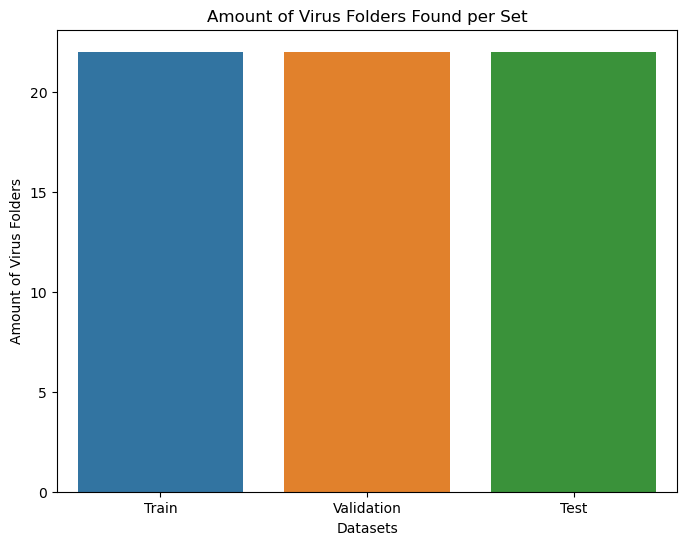

In [6]:
# Plotting the amount of viruses found in each dataset
plt.figure(figsize=(8, 6))
xValues = np.array(["Train", "Validation", "Test"])
yValues = np.array([train_virus_found, validation_virus_found, test_virus_found])
sns.barplot(x=xValues, y=yValues)
plt.title("Amount of Virus Folders Found per Set")
plt.xlabel("Datasets")
plt.ylabel("Amount of Virus Folders")
plt.show()

Function to check that the transmission electron microscopy (TEM) images have their respective tags(.csv) and particle positions(.txt)

In [7]:
# Checking for the TEM Images to confirm their existence along with the respective metadata and particle positions
def check_TEM_files(dataset, viruses):
    dataset_folder = os.path.basename(dataset)
    print(f"Checking {dataset_folder} dataset...")
    total_tif_per_folder = []
    for virus in viruses:
        virus_dir = os.path.join(dataset, virus)
        tif_files = [f for f in os.listdir(virus_dir) if f.endswith(".tif")]
        total_tif_per_folder.append(len(tif_files))
    
        particle_positions_path = os.path.join(virus_dir, 'particle_positions')
        tags_path = os.path.join(virus_dir, 'tags')
        particle_postions_exist = os.path.exists(particle_positions_path)
        tags_exist = os.path.exists(tags_path)
    
        if not particle_postions_exist or not tags_exist:
            print(f"Warning: Missing .txt or .csv file for {virus_dir}")
            return False, total_tif_per_folder
    
        for filename in tif_files:
            base_name = os.path.splitext(filename)[0]
            txt_file = os.path.join(particle_positions_path, base_name + '_particlepositions.txt')
            csv_file = os.path.join(tags_path, base_name + '.tif_tags.csv')
    
            if not os.path.exists(txt_file):
                print(f"Error: Missing .txt file for {txt_file}")
                return False, total_tif_per_folder
            if not os.path.exists(csv_file):
                print(f"Error: Missing .csv file for {csv_file}")
                return False, total_tif_per_folder
    return True, total_tif_per_folder

train_TEM_info, train_tif_count = check_TEM_files(TRAIN_PATH, VIRUSES)
validation_TEM_info, validation_tif_count = check_TEM_files(VALIDATION_PATH, VIRUSES)
test_TEM_info, test_tif_count = check_TEM_files(TEST_PATH, VIRUSES)
print()
if train_TEM_info and validation_TEM_info and test_TEM_info:
    print("All the TEM files, with tags and particle positions were found.")
else:
    print("Some the TEM files, with tags and particle positions were not found.")

Checking train dataset...
Checking validation dataset...
Checking test dataset...

All the TEM files, with tags and particle positions were found.


Calculating the tif amount of files and the quantiles for each dataset

In [8]:
#  Acummulating the values for each stage of the project and adquiring the rounded values from the quantiles 
all_tif_counts = train_tif_count + validation_tif_count + test_tif_count
dataset_labels = ["Train"] * len(train_tif_count) + ["Validation"] * len(validation_tif_count) + ["Test"] * len(test_tif_count)
train_quantiles = np.quantile(train_tif_count, [0.25, 0.5, 0.75])
validation_quantiles = np.quantile(validation_tif_count, [0.25, 0.5, 0.75])
test_quantiles = np.quantile(test_tif_count, [0.25, 0.5, 0.75])

rounded_train_quantiles = [round(q) for q in train_quantiles]
rounded_validation_quantiles = [round(q) for q in validation_quantiles]
rounded_test_quantiles = [round(q) for q in test_quantiles]

Displaying the data analysis and quantile values for the amount of TIF images per folder in each dataset,

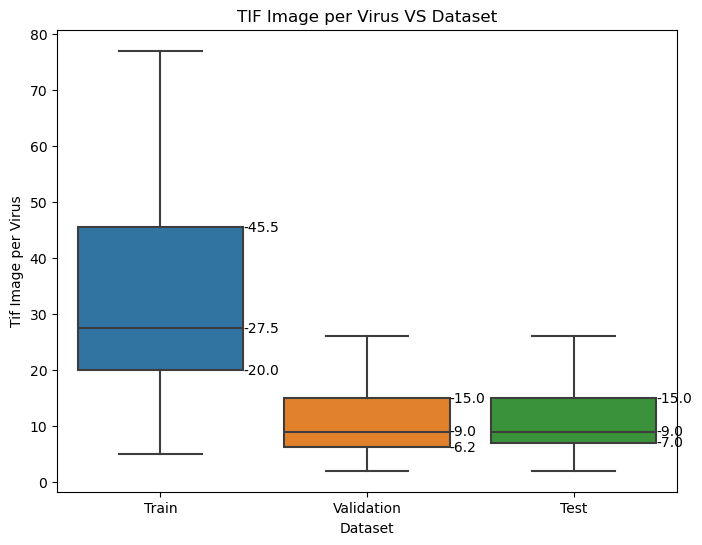

Rounded Median for the data to the nearest non-decimal value
Training Q1 =  20 , Q2 =  28 , Q3 =  46
Validation Q1 =  6 , Q2 =  9 , Q3 =  15
Test Q1 =  7 , Q2 =  9 , Q3 =  15


In [9]:
# Plotting the quantile values of the TIF Images per Virus in each Dataset
plt.figure(figsize=(8,6))
xValues = np.array(dataset_labels)
yValues = np.array(all_tif_counts)
ax = sns.boxplot(x=xValues, y=yValues)
plt.title("TIF Image per Virus VS Dataset")
plt.xlabel("Dataset")
plt.ylabel("Tif Image per Virus")
for index, quantile in enumerate(train_quantiles):
    ax.text(0.4, quantile, f"-{quantile:.1f}", ha="left", va="center", color="black")
for index, quantile in enumerate(validation_quantiles):
    ax.text(1.4, quantile, f"-{quantile:.1f}", ha="left", va="center", color="black")
for index, quantile in enumerate(test_quantiles):
    ax.text(2.4, quantile, f"-{quantile:.1f}", ha="left", va="center", color="black")
plt.show()
print("Rounded Median for the data to the nearest non-decimal value")
print("Training Q1 = ", rounded_train_quantiles[0], ", Q2 = ", rounded_train_quantiles[1], ", Q3 = ", rounded_train_quantiles[2])
print("Validation Q1 = ", rounded_validation_quantiles[0], ", Q2 = ", rounded_validation_quantiles[1], ", Q3 = ", rounded_validation_quantiles[2])
print("Test Q1 = ", rounded_test_quantiles[0], ", Q2 = ", rounded_test_quantiles[1], ", Q3 = ", rounded_test_quantiles[2])

Defining the amount of images I should have per folder in the training set by using the median

In [10]:
# Defining the Q3 value to use in the Augmentation process
train_q3 = rounded_train_quantiles[2]
print(f"Third quantile value: {train_q3}")

Third quantile value: 46


## Extracting and normalising the data

Function to One-Hot Encode the name of the viruses and use them as labels

In [11]:
# One_hot encoding the name of the viruses to reduce noice and use them as labels 
def one_hot_encode_viruses(viruses):
    virus_to_index = {virus: index for index, virus in enumerate(viruses)}
    one_hot_viruses_dict = {virus: np.eye(len(viruses), dtype=int)[index] for virus, index in virus_to_index.items()}
    return one_hot_viruses_dict

Function to resize the pixels of the TEM images and normalise the values

In [12]:
# Resizing using OpenCV library (cv2) and normalising the TEM images to reduce noice
def resize_normalise_tem_image(image_path, target_size=(224, 224)):
    try:
        img = tiff.imread(image_path)
        if not isinstance(img, np.ndarray):
            raise ValueError("Image data is not in a supported format.")
        if img.dtype != np.uint8:
            img = (img - img.min()) / (img.max() - img.min()) * 255
            img = img.astype(np.uint8)
        resized_img = cv2.resize(img, target_size, interpolation=cv2.INTER_AREA)
        normalised_img = resized_img.astype(np.float32) / 255.0

        return normalised_img

    except Exception as e:
        print(f"An error occurred while processing {image_path}: {e}")

        return None

Function to extract the amount and positions of particles that are part of the image

In [13]:
# Extracting the particle positions for each image
# Reallocating the particle to the resized image
# Normalising the pixel location values to reduce noice
def extract_normalise_particle_positions(particle_positions_path, target_size=(224, 224)):
    amount_of_particles = 0
    normalised_positions = []
    with open(particle_positions_path, 'r') as file:
        lines = file.readlines()
    
        original_width, original_height = map(int, lines[1].strip(). split(';'))
        for line in lines[2:]:
            if 'particleposition' in line:
                amount_of_particles += 1
            else:
                try:
                    x, y = map(int, line.strip().split(';'))
                    normalised_x = float((x / original_width) * target_size[0])
                    normalised_y = float((y / original_height) * target_size[1])
                    normalised_positions.append((normalised_x, normalised_y))
        
                except ValueError:
                    continue
    
    return amount_of_particles, normalised_positions

Function to extract only the relevant tags for the machine learning model to train, validate and test

In [14]:
# Extracting the relevant metadata
# Normalising the values used for object detection and segmentation
def extract_normalise_relevant_tags(relevant_tags_path, target_size=(224,224)):
    metadata = pd.read_csv(relevant_tags_path,delimiter =';', header=None, index_col=None)
    keys = metadata[0].tolist()
    values = metadata[1].tolist()
    
    try:
        original_width = int(values[keys.index('Width')])
        original_height = int(values[keys.index('Heigt')])
    
        grid_x = float(str(values[keys.index('GridposX')]).replace(',', '.'))
        grid_y = float(str(values[keys.index('GridposY')]).replace(',', '.'))
        grid_z = float(str(values[keys.index('GridposZ')]).replace(',', '.'))
        x_scale = float(str(values[keys.index('Xscale')]).replace(',', '.'))
        y_scale = float(str(values[keys.index('Yscale')]).replace(',', '.'))
        acc_voltage = int(values[keys.index('AccVoltage')])
        defocus = int(values[keys.index('Defocus')])
        magnification = int(values[keys.index('Magnification')])
        tilt_x = float(str(values[keys.index('TiltX')]).replace(',', '.'))
        tilt_y = float(str(values[keys.index('TiltY')]).replace(',', '.'))
    
        normalised_x_scale = x_scale * (target_size[0] / original_width)
        normalised_y_scale = y_scale * (target_size[1] / original_height)
    
    except ValueError:
        raise ValueError("Error in parsing metadata. Check for missing or incorrectly formatted values.")
    except KeyError:
        raise KeyError("Error: One or more metadata keys are missing.")
    return (grid_x, grid_y, grid_z, normalised_x_scale, normalised_y_scale, acc_voltage, defocus, magnification, tilt_x, tilt_y)

Function to process the virus data

In [15]:
# Processing the virus data
# Calling different functions to extract the data, metadata, and particle positions in the best possible format
def process_virus_data(virus, dataset, one_hot_viruses):
    virus_dir = os.path.join(dataset, virus)
    virus_data =[]
    
    with os.scandir(virus_dir) as entries:
        for entry in entries:
            if entry.is_file() and entry.name.endswith(".tif"):
                base_name = os.path.splitext(entry.name)[0]
                image_path = entry.path
                particle_positions_path = os.path.join(virus_dir, 'particle_positions', base_name + '_particlepositions.txt')
                tags_path = os.path.join(virus_dir, 'tags', base_name + '.tif_tags.csv')
        
                if not os.path.exists(particle_positions_path) and os.path.exists(tags_path):
                    print(f"Missing .txt file for {particle_positions_path}")
        
                try:
                    img = resize_normalise_tem_image(image_path)
                    amount_of_particles, particle_positions = extract_normalise_particle_positions(particle_positions_path)
                    grid_x, grid_y, grid_z, x_scale, y_scale, acc_voltage, defocus, magnification, tilt_x, tilt_y = extract_normalise_relevant_tags(tags_path)
                    virus_data.append({
                        "image": img,
                        "width": 224,
                        "height": 224,
                        "virus_label": one_hot_viruses[virus],
                        "amount_of_particles": amount_of_particles,
                        "particle_positions": particle_positions,
                        "grid_x": grid_x,
                        "grid_y": grid_y,
                        "grid_z": grid_z,
                        "x_scale": x_scale,
                        "y_scale": y_scale,
                        "acc_voltage": acc_voltage,
                        "defocus": defocus,
                        "magnification": magnification,
                        "tilt_x": tilt_x,
                        "tilt_y": tilt_y
                    })
                except Exception as e:
                    print(f"Error processing {entry.name}: {e}")
    
    return virus_data

Function to multiprocess the extraction of the training, validation and testing data

In [16]:
# Multiprocessing the data extraction to accelerate the process
# Organising the data extracted by the corresponding label
def multiprocessed_data_extraction(dataset, viruses):
    current_dataset = os.path.basename(dataset)
    print(f"Extracting data from {current_dataset} dataset...")
    all_data = []
    one_hot_viruses = one_hot_encode_viruses(viruses)
    
    with concurrent.futures.ThreadPoolExecutor() as executor:
        futures = {executor.submit(process_virus_data, virus, dataset, one_hot_viruses): virus for virus in viruses}
        for future in concurrent.futures.as_completed(futures):
            all_data.extend(future.result())
    
    organised_data = {}
    
    for item in all_data:
        virus_label = tuple(item["virus_label"])
        if virus_label not in organised_data:
            organised_data[virus_label] = []
        organised_data[virus_label].append(item)
    
    
    return organised_data

train_data = multiprocessed_data_extraction(TRAIN_PATH, VIRUSES)
validation_data = multiprocessed_data_extraction(VALIDATION_PATH, VIRUSES)
test_data = multiprocessed_data_extraction(TEST_PATH, VIRUSES)

print("Processed Data extraction for all the datasets completed.")

Extracting data from train dataset...
Extracting data from validation dataset...
Extracting data from test dataset...
Processed Data extraction for all the datasets completed.


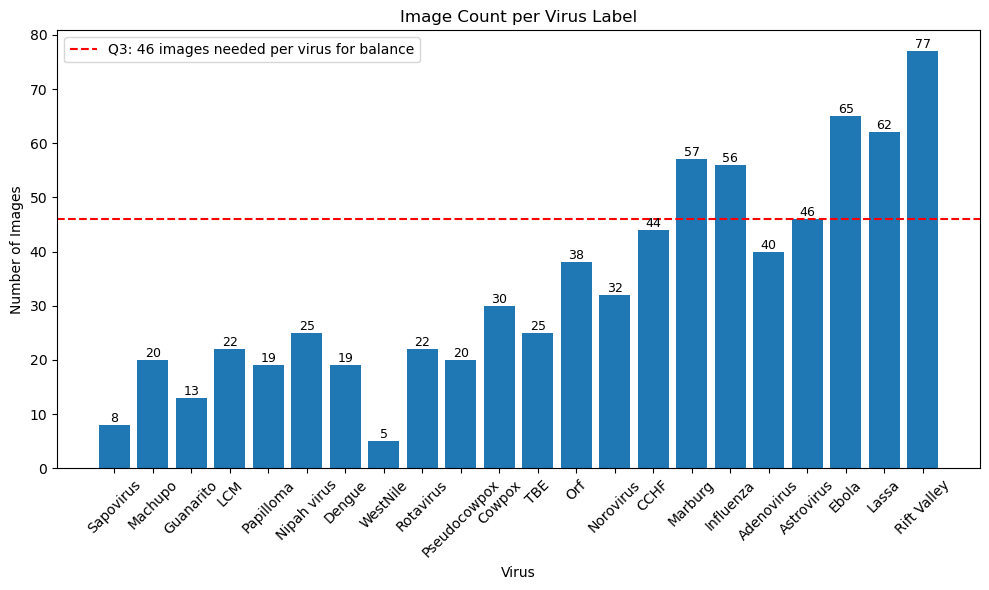

In [17]:
# Printing the amount of images extracted per label 
virus_counts = {}
for virus_label in train_data:
    virus_index = np.argmax(virus_label)
    virus_name = VIRUSES[virus_index]
    if virus_name not in virus_counts:
        virus_counts[virus_name] = 0
    virus_counts[virus_name] += len(train_data[virus_label])

plt.figure(figsize=(10, 6))
bars = plt.bar(virus_counts.keys(), virus_counts.values())
plt.xlabel("Virus")
plt.ylabel("Number of Images")
plt.title("Image Count per Virus Label")
plt.xticks(rotation=45)
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width() / 2, height, str(height), 
             ha='center', va='bottom', fontsize=9)
plt.axhline(train_q3, color='red', linestyle='--', label=f'Q3: {int(train_q3)} images needed per virus for balance')
plt.legend()
plt.tight_layout()
plt.show()

## Augmenting the Training Dataset for Balance

Function to horizontally mirror the image data

In [18]:
# Mirroring left to right the image pixel values and the pixel locations of the particle position
def mirror_image_and_metadata(image):
    image['image'] = np.fliplr(image['image'])
    width = image['image'].shape[1]
    image['particle_positions'] = [(width - 1 - x, y) for x, y in image['particle_positions']]

    return image

Function to mirror the images

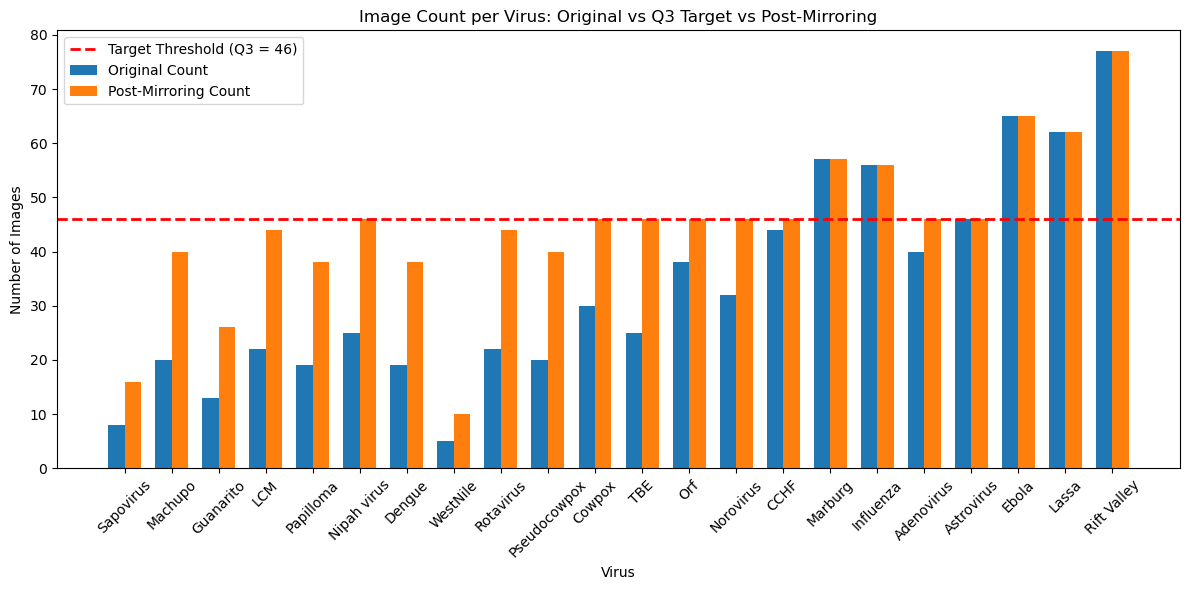

Data mirroring complete.


In [19]:
# Managing the mirroring of the data and printing the amount of mirroring executed per label
def mirrored_data(data, target_count):
    augmented_data = copy.deepcopy(data)

    virus_names = []
    original_counts = []
    mirrored_counts = []
    q3_targets = []
    
    for virus_label, group in data.items():
        original_items_count = len(group)
        mirroring_applied = 0
        virus_index = np.argmax(virus_label)
        virus_name = VIRUSES[virus_index]
    
        for image in group:
            if (mirroring_applied + original_items_count) >= target_count:
                break
            mirrored_image = mirror_image_and_metadata(copy.deepcopy(image))
            augmented_data[virus_label].append(mirrored_image)
            mirroring_applied +=1
        final_count = len(augmented_data[virus_label])

        virus_names.append(virus_name)
        original_counts.append(original_items_count)
        mirrored_counts.append(final_count)
        q3_targets.append(target_count)

    x = np.arange(len(virus_names))
    bar_width = 0.35
    plt.figure(figsize=(12, 6))
    plt.bar(x - bar_width/2, original_counts, width=bar_width, label='Original Count')
    plt.bar(x + bar_width/2, mirrored_counts, width=bar_width, label='Post-Mirroring Count')
    plt.axhline(target_count, color='red', linestyle='--', linewidth=2, label=f'Target Threshold (Q3 = {int(target_count)})')
    plt.xlabel("Virus")
    plt.ylabel("Number of Images")
    plt.title("Image Count per Virus: Original vs Q3 Target vs Post-Mirroring")
    plt.xticks(x, virus_names, rotation=45)
    plt.legend()
    plt.tight_layout()
    plt.show()
        
    return augmented_data

mirrored_train_data = mirrored_data(train_data, train_q3)
print("Data mirroring complete.")

Function to rotate the image to a given angle

In [20]:
# Rotating all the data by 90, 180, and 270 degree and recalculating the location of the particle positions
def rotate_image_and_metadata(image, angle):
    rotation_functions = {
        90: lambda img: np.rot90(img, k=-1, axes=(0, 1)),
        180: lambda img: np.rot90(img, k=-2, axes=(0, 1)),
        270: lambda img: np.rot90(img, k=-3, axes=(0, 1))
    }
    image['image'] = rotation_functions[angle](image['image'])
    
    height, width = image['image'].shape[:2]
    center_y, center_x = height // 2, width // 2
    
    rotated_particle_positions = []
    angle = -math.radians(angle)
    
    for x, y in image['particle_positions']:
        translate_x, translate_y = x - center_x, y - center_y
        new_x = translate_x * math.cos(angle) + translate_y * math.sin(angle) + center_x
        new_y = -translate_x * math.sin(angle) + translate_y * math.cos(angle) + center_y
        rotated_particle_positions.append((new_x, new_y))
    
    image['particle_positions'] = rotated_particle_positions
    
    return image

Function to add more data by rotation of the images

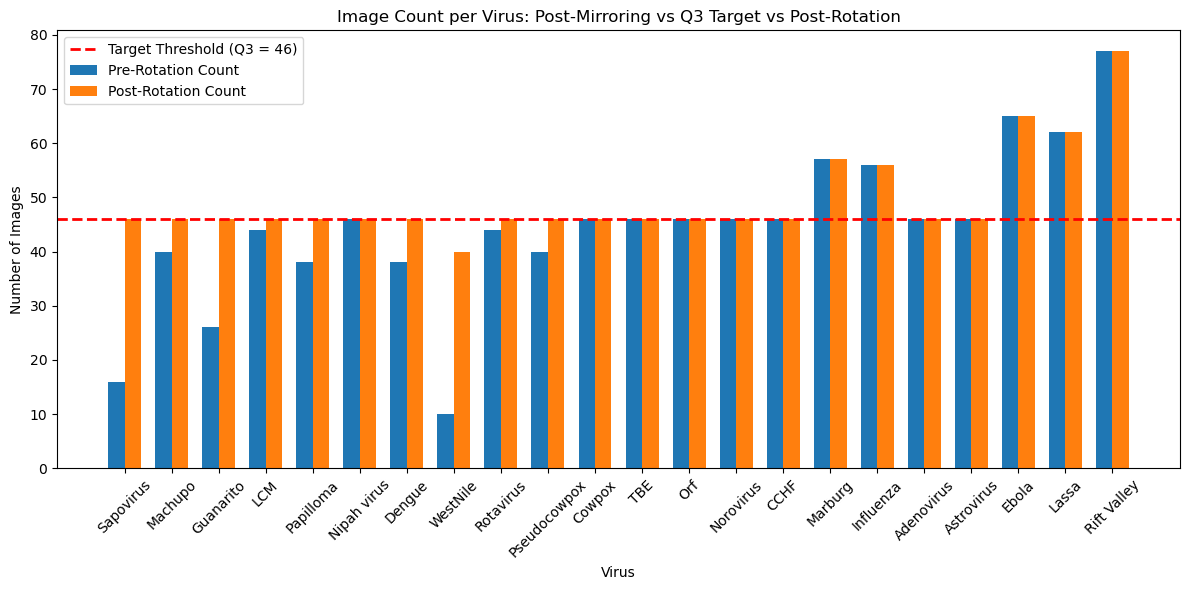

Data rotation complete.


In [21]:
# Managing the rotation of the data and printing the amount of rotations executed per label
def rotated_data(data, target_count):
    augmented_data = copy.deepcopy(data)

    virus_names = []
    original_counts = []
    rotated_counts = []
    
    for virus_label, group in data.items():
        items_count = len(group)
        rotation_applied = 0
        virus_index = np.argmax(virus_label)
        virus_name = VIRUSES[virus_index]
        
        for image in group:
            if (rotation_applied + items_count) >= target_count:
                break
            for angle in [90, 180, 270]:
                if (rotation_applied + items_count) >= target_count:
                    break
                rotated_image = rotate_image_and_metadata(copy.deepcopy(image), angle)
                augmented_data[virus_label].append(rotated_image)
                rotation_applied += 1
        final_count = len(augmented_data[virus_label])

        virus_names.append(virus_name)
        original_counts.append(items_count)
        rotated_counts.append(final_count)
        
    x = np.arange(len(virus_names))
    bar_width = 0.35
    plt.figure(figsize=(12, 6))
    plt.bar(x - bar_width/2, original_counts, width=bar_width, label='Pre-Rotation Count')
    plt.bar(x + bar_width/2, rotated_counts, width=bar_width, label='Post-Rotation Count')
    plt.axhline(target_count, color='red', linestyle='--', linewidth=2, label=f'Target Threshold (Q3 = {int(target_count)})')
    plt.xlabel("Virus")
    plt.ylabel("Number of Images")
    plt.title("Image Count per Virus: Post-Mirroring vs Q3 Target vs Post-Rotation")
    plt.xticks(x, virus_names, rotation=45)
    plt.legend()
    plt.tight_layout()
    plt.show()
    
    return augmented_data

rotated_train_data = rotated_data(mirrored_train_data, train_q3)
print("Data rotation complete.")

In [22]:
# Printing the total amount of data after augmentation
count=0
for virus_label in rotated_train_data:
    count += len(rotated_train_data[virus_label])
print(count)

1093


## Transforming data into COCO format

Function to calculate the bbox size using the magnification of each image

In [23]:
# Creating the box size using average reference values for magnification and box size 
def compute_bbox_size(magnification, magnification_ref=50000, bbox_size_ref=20):
    if magnification <= 0:
        return bbox_size_ref
    return bbox_size_ref * (magnification_ref / magnification)

Function to create COCO JSON Structure

In [24]:
# Structuring the data as a COCO JSON structure for future use in the ML model
def create_JSON_structure(image_id, data, viruses, annotation_start_id):
    img_array = data["image"]
    one_hot_encoded_label = data["virus_label"]
    img_array_to_list = img_array.tolist()
    one_hot_encoded_label_to_list = one_hot_encoded_label.tolist()
    virus_index = int(np.argmax(one_hot_encoded_label))
    virus_name = viruses[virus_index]
    category_id = virus_index + 1
    
    particle_positions = data["particle_positions"]
    magnification = data["magnification"]
    bbox_size = compute_bbox_size(magnification)
    image_info = {
        "id": image_id,
        "width": data["width"],
        "height": data["height"],
        "image_pixel_values": img_array_to_list,
        "virus_label": one_hot_encoded_label_to_list,
        "magnification": magnification
    }
    annotation_info = [
        {
            "id": annotation_start_id + annotation_id,
            "image_id": image_id,
            "category_id": category_id,
            "virus_label": one_hot_encoded_label_to_list,
            "particle_center": [x,y],
            "segmentation": [[x - bbox_size/2, y - bbox_size/2,
                              x + bbox_size/2, y - bbox_size/2,
                              x + bbox_size/2, y + bbox_size/2,
                              x - bbox_size/2, y + bbox_size/2]],
            "bbox": [x - bbox_size/2, y - bbox_size/2, bbox_size, bbox_size],
            "area": bbox_size * bbox_size,
            "iscrowd": 0
        }
        for annotation_id, (x, y) in enumerate(particle_positions)
    ]
    
    return image_info, annotation_info

Creating, and storing the COCO JSON structure

In [25]:
# Checking for COCO JSON files
# Removing any existing file to maintain the data updated 
# Saving the new JSON data and creating a new JSON file
def create_coco_json(dataset, viruses, extracted_data):
    current_dataset = os.path.basename(dataset)
    coco_annotation_path = current_dataset + '_coco_annotations.json'
    coco_output_path = './' + coco_annotation_path
    
    if os.path.exists(coco_output_path):
        os.remove(coco_output_path)
        print(f"Removed existing {coco_annotation_path} file.")
    
    coco_dict = {
        "images": [],
        "annotations": [],
        "categories": [{"id": index + 1, "name": virus} for index, virus in enumerate(viruses)]
    }
    
    image_id = 1
    annotation_id = 1
    results = []
    
    with concurrent.futures.ThreadPoolExecutor() as executor:
        futures = []
        for data_list in extracted_data.values():
            for data in data_list:
                futures.append(executor.submit(create_JSON_structure, image_id, data, viruses, annotation_id))
                image_id += 1
                annotation_id += len(data["particle_positions"])
    
        for future in concurrent.futures.as_completed(futures):
            results.append(future.result())
    
    for image_info, annotation_info in results:
        coco_dict["images"].append(image_info)
        coco_dict["annotations"].extend(annotation_info)
    
    with open(coco_output_path, 'w') as f:
        json.dump(coco_dict, f, indent=4)
    print(f"COCO annotations saved to {coco_annotation_path}")

create_coco_json(TRAIN_PATH, VIRUSES, rotated_train_data)
create_coco_json(VALIDATION_PATH, VIRUSES, validation_data)
create_coco_json(TEST_PATH, VIRUSES, test_data)

Removed existing train_coco_annotations.json file.
COCO annotations saved to train_coco_annotations.json
Removed existing validation_coco_annotations.json file.
COCO annotations saved to validation_coco_annotations.json
Removed existing test_coco_annotations.json file.
COCO annotations saved to test_coco_annotations.json


displaying an image and with all the particle position from the COCO file

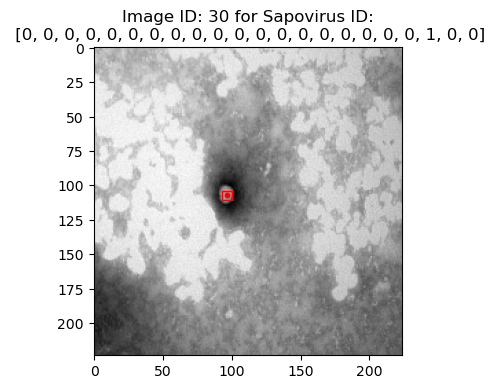

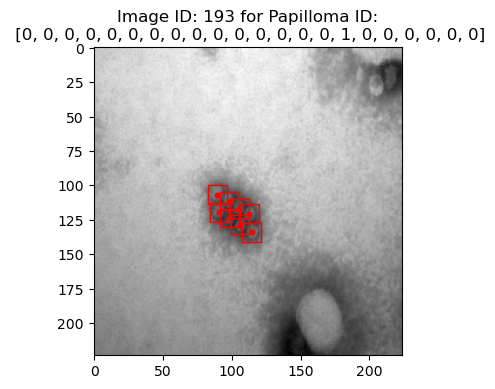

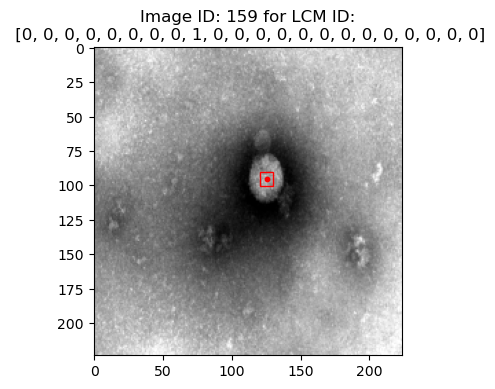

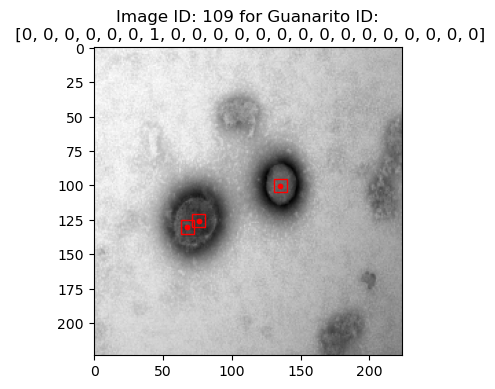

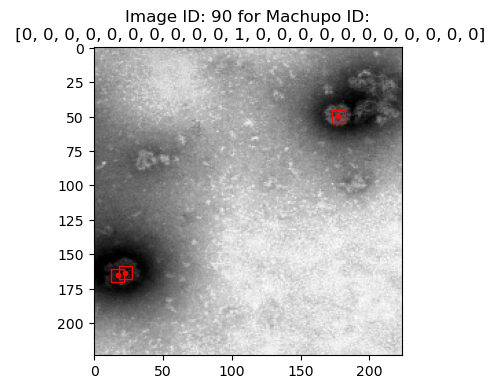

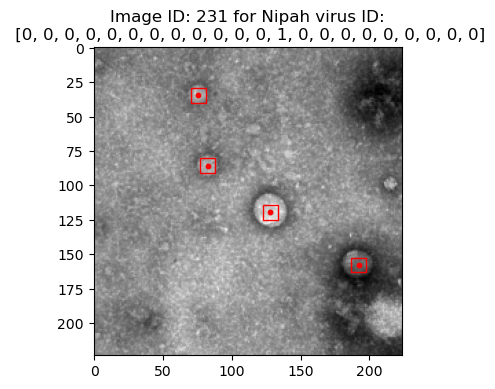

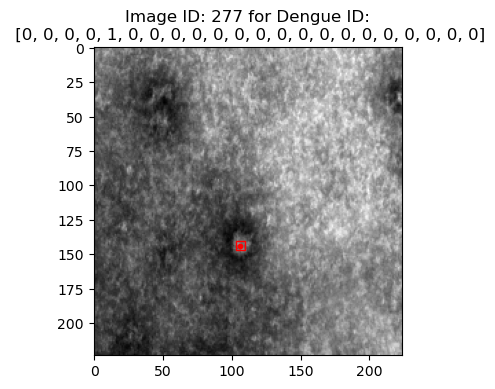

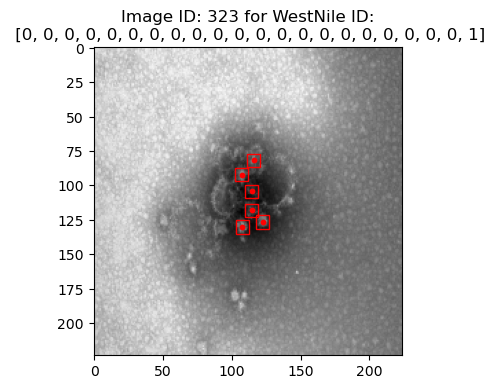

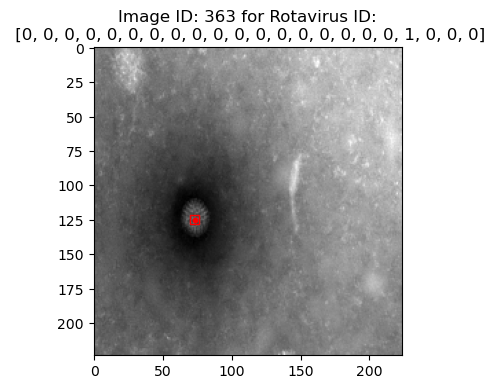

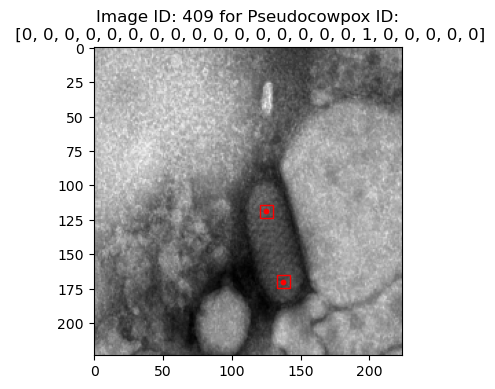

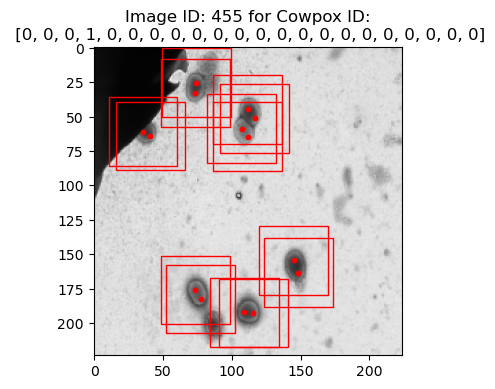

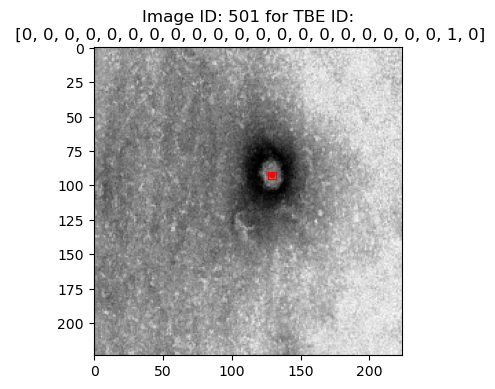

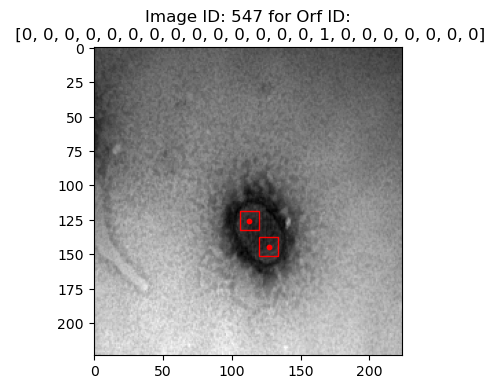

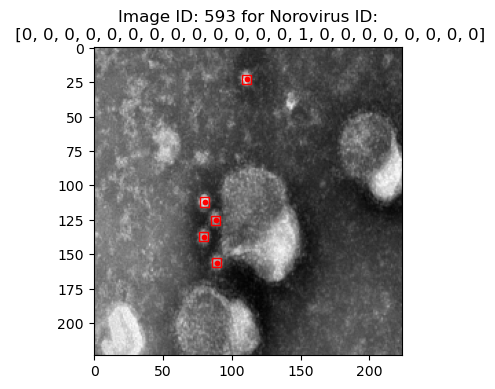

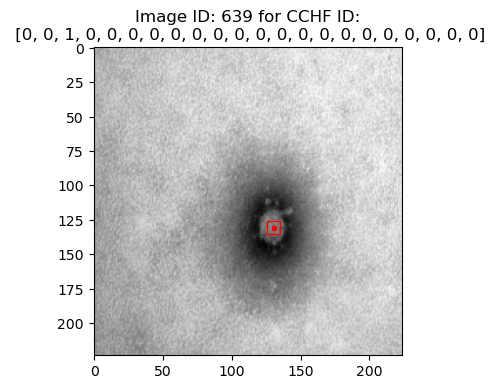

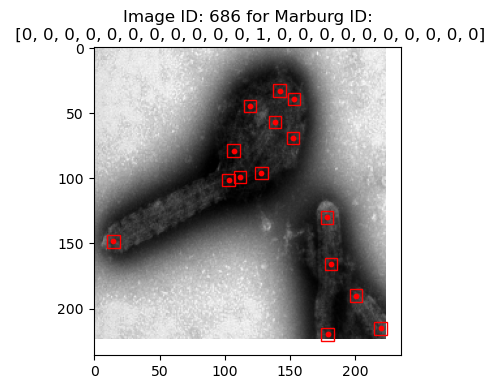

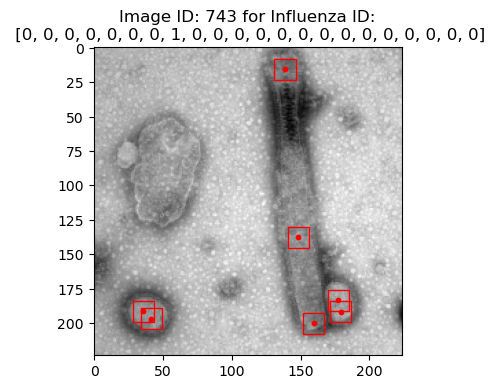

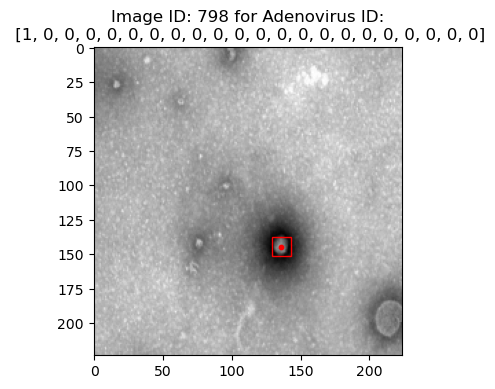

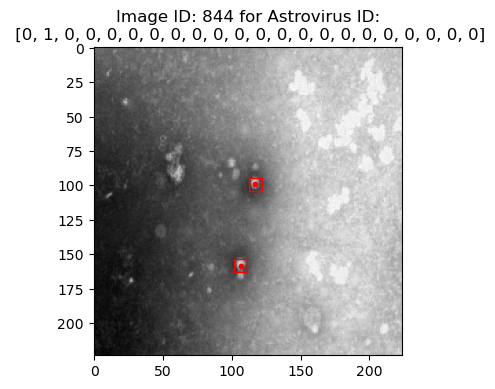

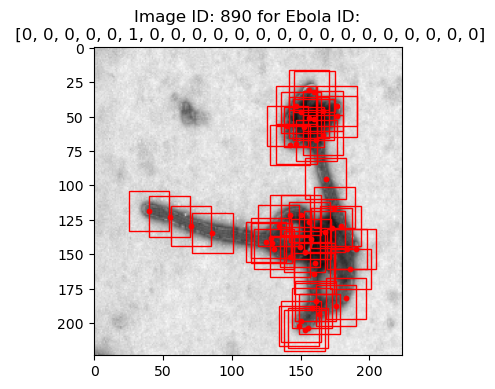

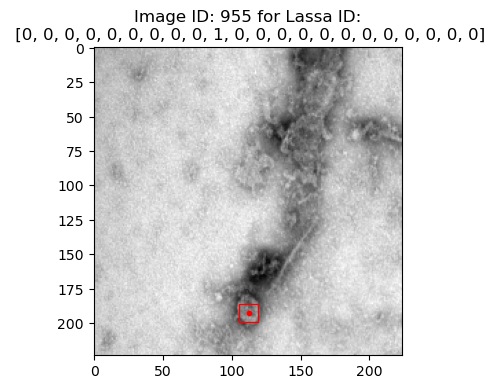

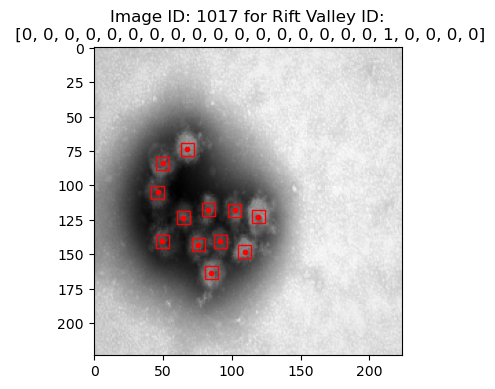

In [26]:
# Displaying one image for every existing virus using the training data stored in the JSON file
def display_coco_image_single(coco_json_path, viruses):
    with open(coco_json_path, 'r') as f:
        coco_data = json.load(f)
    
    images = coco_data["images"]
    annotations = coco_data["annotations"]
    
    Selected_virus_images = {}
    
    for image_data in images:
        image_id = image_data["id"]
        image_array = np.array(image_data["image_pixel_values"])
        image_annotations = [anno for anno in annotations if anno["image_id"] == image_id]
        virus_label = image_data["virus_label"]
        virus_index = virus_label.index(1)
        virus_name = viruses[virus_index]
    
        if virus_name not in Selected_virus_images:
            Selected_virus_images[virus_name] = []
        if len(Selected_virus_images[virus_name]) >= 1:
            continue
        Selected_virus_images[virus_name].append((image_id, image_array, image_annotations))
    
        plt.figure(figsize=(4,4))
        plt.imshow(image_array, cmap="gray")
        plt.title(f"Image ID: {image_id} for {virus_name} ID:\n {virus_label}")
        for annotation in image_annotations:
            x, y = annotation["particle_center"]
            plt.scatter(x, y, color='red', s=10, label='Particle Position')
            xbbox, ybbox, w, h = annotation["bbox"]
            rect = plt.Rectangle((xbbox, ybbox), w, h, linewidth=1, edgecolor='red', facecolor='none')
            plt.gca().add_patch(rect)
        plt.show()

coco_train_path = "./train_coco_annotations.json"
display_coco_image_single(coco_train_path, VIRUSES)

# **Training the Faster R-CNN model**

## Adding all the libraries

Check and install libraries for the Faster R-CNN Model

In [11]:
import torch
import torchvision
from torch.utils.data import Dataset, DataLoader
import torchvision.models.detection as detection
import torch.optim as optim
from tqdm import tqdm
from pycocotools.coco import COCO
from collections import Counter

## Using the data from the COCO JSON files

In [12]:
# Class that extracts the data of each json file 
# Structuring the data for the ML Model
# Preparing the data in batches
class COCO_Virus_Dataset(Dataset):

    def __init__(self, json_file, transforms=None):
        self.transforms = transforms
        self.coco = COCO(json_file)
        self.image_ids = list(self.coco.imgs.keys())
    
    def __getitem__(self, index):
        image_id = self.image_ids[index]
        image_info = self.coco.imgs[image_id]
        image = image_info["image_pixel_values"]
        image = torch.tensor(image).unsqueeze(0) 
        if image.shape[0] == 1:
            image = image.repeat(3, 1, 1)
            
        annotations = self.coco.loadAnns(self.coco.getAnnIds(imgIds=image_id))
        boxes = []
        labels = []
        for annotation in annotations:
            xbbox, ybbox, w, h = annotation["bbox"]
            boxes.append([xbbox, ybbox, xbbox + w, ybbox + h])
            labels.append(annotation["category_id"])
    
        boxes = torch.tensor(boxes, dtype=torch.float32)
        labels = torch.tensor(labels, dtype=torch.int64)
    
        target = {
            "boxes": boxes,
            "labels": labels
        }
    
        return image, target
    
    def __len__(self):
        
        return len(self.image_ids)

train_json = "./train_coco_annotations.json"
val_json = "./validation_coco_annotations.json"
test_json = "./test_coco_annotations.json"

train_dataset = COCO_Virus_Dataset(train_json)
val_dataset = COCO_Virus_Dataset(val_json)
test_dataset = COCO_Virus_Dataset(test_json)

train_loader = DataLoader(train_dataset, batch_size=1, shuffle=True, collate_fn=lambda x: tuple(zip(*x)))
val_loader = DataLoader(val_dataset, batch_size=1, shuffle=False, collate_fn=lambda x: tuple(zip(*x)))
test_loader = DataLoader(test_dataset, batch_size=1, shuffle=False, collate_fn=lambda x: tuple(zip(*x)))

loading annotations into memory...
Done (t=21.57s)
creating index...
index created!
loading annotations into memory...
Done (t=4.66s)
creating index...
index created!
loading annotations into memory...
Done (t=5.06s)
creating index...
index created!


In [13]:
# Confirming the length of the train dataset
print(train_dataset.__len__())

1093


In [14]:
# Printing an item from the dataset to confirm that the structure of the data is correct
print(train_dataset.__getitem__(10))

(tensor([[[0.5647, 0.5647, 0.5608,  ..., 0.8000, 0.8471, 0.7882],
         [0.5608, 0.5686, 0.5529,  ..., 0.7882, 0.8118, 0.7647],
         [0.5451, 0.5529, 0.5569,  ..., 0.8078, 0.8118, 0.8235],
         ...,
         [0.7451, 0.7922, 0.8118,  ..., 0.8667, 0.8157, 0.8157],
         [0.8039, 0.8000, 0.8235,  ..., 0.8314, 0.8118, 0.8627],
         [0.8314, 0.8157, 0.8039,  ..., 0.8275, 0.8196, 0.8510]],

        [[0.5647, 0.5647, 0.5608,  ..., 0.8000, 0.8471, 0.7882],
         [0.5608, 0.5686, 0.5529,  ..., 0.7882, 0.8118, 0.7647],
         [0.5451, 0.5529, 0.5569,  ..., 0.8078, 0.8118, 0.8235],
         ...,
         [0.7451, 0.7922, 0.8118,  ..., 0.8667, 0.8157, 0.8157],
         [0.8039, 0.8000, 0.8235,  ..., 0.8314, 0.8118, 0.8627],
         [0.8314, 0.8157, 0.8039,  ..., 0.8275, 0.8196, 0.8510]],

        [[0.5647, 0.5647, 0.5608,  ..., 0.8000, 0.8471, 0.7882],
         [0.5608, 0.5686, 0.5529,  ..., 0.7882, 0.8118, 0.7647],
         [0.5451, 0.5529, 0.5569,  ..., 0.8078, 0.8118, 0

## Loading, modifying and visualising the pretrained Faster R-CNN

Model setup for Object Detection

In [15]:
# Setting the Faster R-CNN
# Defining the classes to be used(the viruses) and adding an extra one (background)
# Specifying and loading the pretrained model
# Modifying the model's prediction head to match the number of classes defined
# Setting the device to use GPU if available to be able to run the code faster
num_classes = len(VIRUSES) + 1
COCO_pretrained_weights = detection.FasterRCNN_ResNet50_FPN_Weights.DEFAULT
model = detection.fasterrcnn_resnet50_fpn(weights=COCO_pretrained_weights)

in_features = model.roi_heads.box_predictor.cls_score.in_features
model.roi_heads.box_predictor = detection.faster_rcnn.FastRCNNPredictor(in_features, num_classes)

device = torch.device("cuda") if torch.cuda.is_available() else torch.device("cpu")
print(f"Using device: {device}")
model.to(device)

if device.type == 'cuda':
    torch.backends.cudnn.benchmark = True

Using device: cuda


In [16]:
# Extracting as a table the information of model, transform, backbone, count layers and bottlenecks, FPN, RPN, and ROI Heads
def extract_model_info(model):
    data = []
    
    data.append(["Model Type", model.__class__.__name__])
    data.append(["Backbone", f"{model.backbone.__class__.__name__}"])
    data.append(["Total Parameters", f"{sum(p.numel() for p in model.parameters())/1e6:.2f}M"])
    data.append(["Input Channels", model.backbone.body.conv1.in_channels])
    data.append(["", ""])
    
    transform = model.transform
    try:
        data.append(["Image Normalization Mean", str(transform.image_mean)])
        data.append(["Image Normalization Std", str(transform.image_std)])
    except AttributeError:
        try:
            data.append(["Image Normalization Mean", str(transform.mean)])
            data.append(["Image Normalization Std", str(transform.std)])
        except AttributeError:
            data.append(["Image Normalization", "Not accessible"])
    try:
        min_size = transform.min_size[0] if isinstance(transform.min_size, (list, tuple)) else transform.min_size
        data.append(["Image Resizing", f"Min: {min_size}, Max: {transform.max_size}"])
    except AttributeError:
        data.append(["Image Resizing", "Not accessible"])
    data.append(["", ""])
    
    backbone = model.backbone.body
    conv1 = backbone.conv1
    data.append(["Initial Convolution", 
                f"Conv2d(in={conv1.in_channels}, out={conv1.out_channels}, "
                f"kernel_size={conv1.kernel_size}, stride={conv1.stride})"])
    
    layer_counts = {}
    for name, module in backbone.named_children():
        if name.startswith('layer'):
            layer_num = name[5:]
            layer_counts[f"Layer {layer_num} blocks"] = len(module)
    for layer, count in layer_counts.items():
        data.append([layer, count])
    data.append(["Total Bottleneck Blocks", sum(layer_counts.values())])
    data.append(["", ""])
    
    fpn = model.backbone.fpn
    data.append(["FPN Input Channels", str([block[0].in_channels for block in fpn.inner_blocks])])
    data.append(["FPN Output Channels", fpn.layer_blocks[0][0].out_channels])
    data.append(["", ""])
    
    rpn = model.rpn
    rpn_conv = rpn.head.conv[0][0]
    data.append(["RPN Convolution", 
                f"Conv2d(in={rpn_conv.in_channels}, out={rpn_conv.out_channels}, "
                f"kernel_size={rpn_conv.kernel_size})"])
    data.append(["RPN Anchors per Location", rpn.anchor_generator.num_anchors_per_location()[0]])
    data.append(["RPN Output Channels", rpn_conv.out_channels])
    data.append(["", ""]) 
    
    roi_heads = model.roi_heads
    data.append(["ROI Pooling", 
                f"MultiScaleRoIAlign(featmaps={roi_heads.box_roi_pool.featmap_names}, "
                f"output_size={roi_heads.box_roi_pool.output_size})"])
    data.append(["ROI Head", 
                f"TwoMLPHead({roi_heads.box_head.fc6.in_features}->"
                f"{roi_heads.box_head.fc6.out_features}->"
                f"{roi_heads.box_head.fc7.out_features})"])
    data.append(["Number of Classes", roi_heads.box_predictor.cls_score.out_features])
    data.append(["BBox Regression Features", roi_heads.box_predictor.bbox_pred.out_features])
    
    return data

model_info = extract_model_info(model)

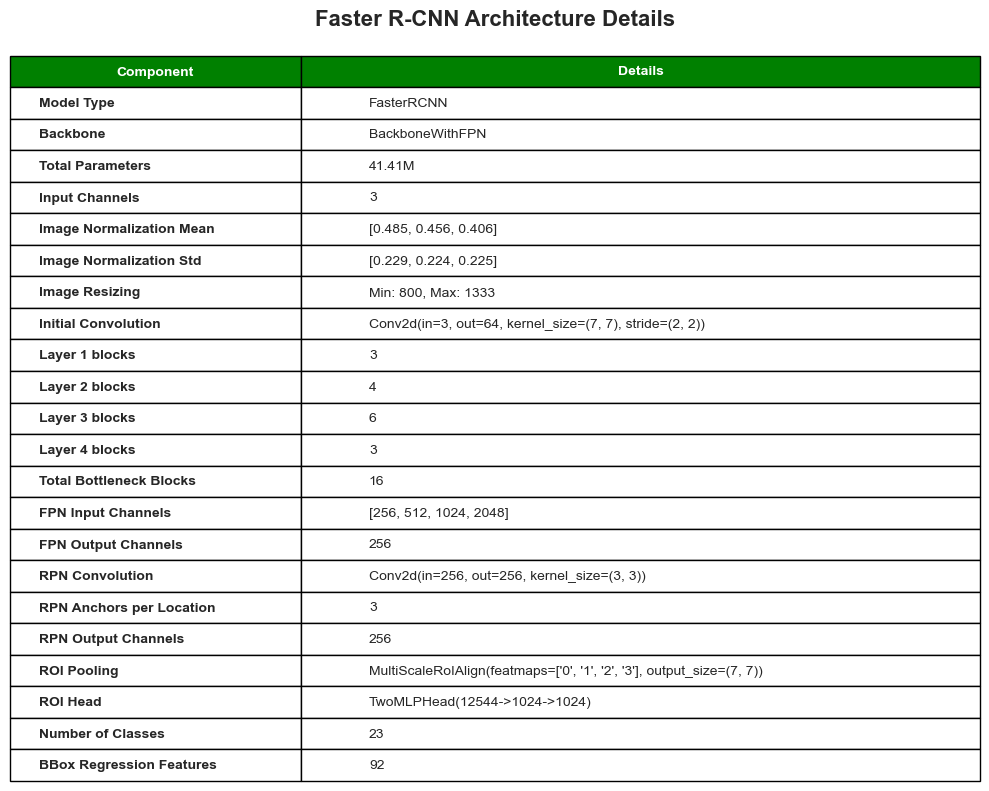

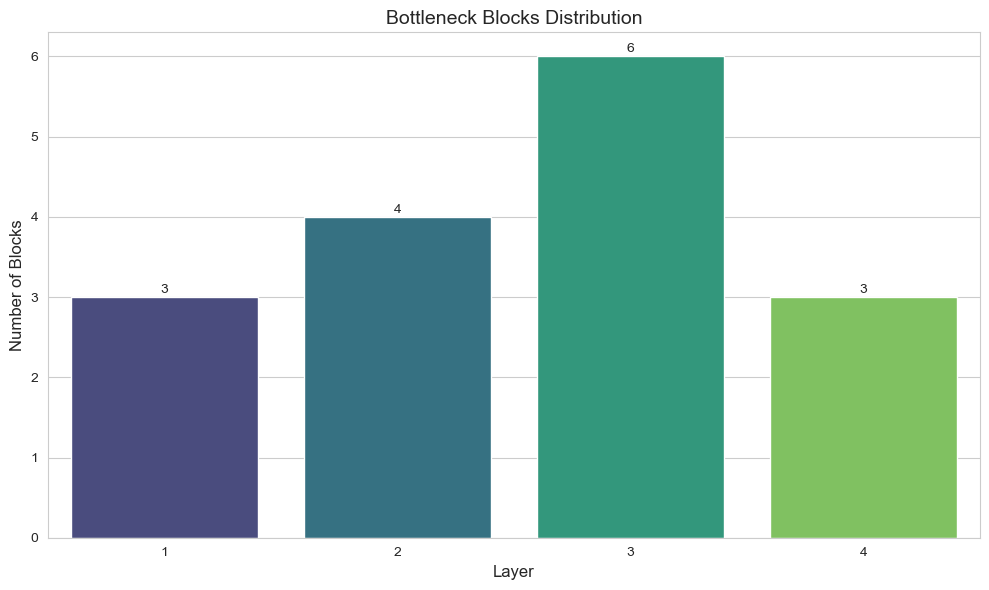

In [17]:
# Converting the model information into a DataFrame
# Formatting a table for the model components and specifications
# Showing the bottleneck blocks across the model layers
def visualize_model_info(model_info):
    df = pd.DataFrame(model_info, columns=["Component", "Details"])
    plot_df = df[df["Component"] != ""].copy()
    
    sns.set_style("whitegrid")
    plt.figure(figsize=(10, 8))
    ax = plt.gca()
    ax.axis('off')
    
    table = plt.table(cellText=plot_df.values,
                     colLabels=plot_df.columns,
                     cellLoc='left',
                     loc='center',
                     colWidths=[0.3, 0.7])
    
    table.auto_set_font_size(False)
    table.set_fontsize(10)
    table.scale(1, 1.8)
    
    for (row_idx, col_idx), cell in table.get_celld().items():
        if row_idx == 0:
            cell.set_text_props(weight='bold', color='white')
            cell.set_facecolor('green')
        else:
            if col_idx == 0:
                cell.set_text_props(weight='bold')
    
    plt.title("Faster R-CNN Architecture Details", pad=50, fontsize=16, weight='bold')
    plt.tight_layout()
    
    blocks_data = []
    for _, row in plot_df.iterrows():
        if "blocks" in row["Component"]:
            layer = row["Component"].split()[1]
            blocks = int(row["Details"])
            blocks_data.append({"Layer": layer, "Blocks": blocks})
    
    if blocks_data:
        plt.figure(figsize=(10, 6))
        blocks_df = pd.DataFrame(blocks_data)
        ax = sns.barplot(x="Layer", y="Blocks", data=blocks_df, palette="viridis")
        plt.title("Bottleneck Blocks Distribution", fontsize=14)
        plt.xlabel("Layer", fontsize=12)
        plt.ylabel("Number of Blocks", fontsize=12)

        for bar in ax.patches:
            ax.annotate(f"{int(bar.get_height())}", 
                        (bar.get_x() + bar.get_width() / 2., bar.get_height()),
                        ha='center', va='center', 
                        xytext=(0, 5), 
                        textcoords='offset points',
                        fontsize=10)
        
        plt.tight_layout()

visualize_model_info(model_info)

In [18]:
print(model)

FasterRCNN(
  (transform): GeneralizedRCNNTransform(
      Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
      Resize(min_size=(800,), max_size=1333, mode='bilinear')
  )
  (backbone): BackboneWithFPN(
    (body): IntermediateLayerGetter(
      (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
      (bn1): FrozenBatchNorm2d(64, eps=0.0)
      (relu): ReLU(inplace=True)
      (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
      (layer1): Sequential(
        (0): Bottleneck(
          (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
          (bn1): FrozenBatchNorm2d(64, eps=0.0)
          (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
          (bn2): FrozenBatchNorm2d(64, eps=0.0)
          (conv3): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
          (bn3): FrozenBatchNorm2d(256, eps=0.0)
          (relu): ReLU(

## Training the model

In [27]:
# Setting up the parameters for the training 
hyperparams = {
    "learning_rate": [0.00001],
    "step": [8],
    "gamma": [0.1],
    "num_epochs": [20]
}

In [28]:
# Evaluating the accuracy of labels predictions per high score bounding box.
# Extracting the most common label prediction with the help of Counter.
# Calculating the percentage of predictions that matched the expected label.
# Returning the percentage and the most common label.
def percentage_to_label(expected_label, predicted_filtered_labels):
    percentage_achieved = 0.0
    most_common_label_pred = 0

    if not predicted_filtered_labels:
        return percentage_achieved, most_common_label_pred

    label_counts = Counter(predicted_filtered_labels)
    most_common_label_pred, _ = label_counts.most_common(1)[0]
    matching_count = label_counts.get(expected_label, 0)
    percentage_achieved = (matching_count / len(predicted_filtered_labels)) * 100
    
    return percentage_achieved, most_common_label_pred 

In [29]:
# Calculating all the metrics 
def calculating_metrics(expected_labels, common_predicted_labels):
    true_positives = 0
    false_positives = 0
    false_negatives = 0
                    
    for e_l, c_p_l in zip(expected_labels, common_predicted_labels):     
        if e_l == c_p_l and e_l != 0:
            true_positives += 1
        elif e_l != c_p_l and c_p_l != 0:
            false_positives += 1
        elif c_p_l == 0:
            false_negatives += 1
                            
    accuracy = true_positives / len(expected_labels)
    precision = true_positives / (true_positives + false_positives)
    recall = true_positives / (true_positives + false_negatives)
    f1_score = 2 * (precision * recall) / (precision + recall)

    return accuracy, precision, recall, f1_score

In [30]:
# Setting the model to training mode.
# Looping through the data and moving it to the device defined earlier for computation.
# Resetting the gradients of the optimiser before each batch to avoid incorrect updates.
# Calculating all the individual losses returned by the model for different aspects (Classification, Bounding Box Regression, 
# Objectness, and Region Proposal Network Box Regression).
# Backpropagation to calculate the gradients of the loss 
# Updating the model's parameters based on the calculated gradients with optimiser
# Accumulating the losses per epoch and displaying them
def train_one_epoch(model, optimiser, data_loader, device):
    model.train()
    num_batches = len(data_loader)
    
    running_loss_classifier = 0.0
    running_loss_box_reg = 0.0
    running_loss_objectness = 0.0
    running_loss_rpn_box_reg = 0.0
    
    total_loss = 0.0
    scaler = torch.cuda.amp.GradScaler()
  
    for images, targets in tqdm(data_loader, desc="Training"):
        images = list(image.to(device)for image in images)
        targets = [{key: value.to(device) for key, value in target.items()} for target in targets]
        optimiser.zero_grad()

        if device.type == 'cuda':
            loss_dict = model(images, targets)
            
            running_loss_classifier += loss_dict['loss_classifier'].item()
            running_loss_box_reg += loss_dict['loss_box_reg'].item()
            running_loss_objectness += loss_dict['loss_objectness'].item()
            running_loss_rpn_box_reg += loss_dict['loss_rpn_box_reg'].item()
            
            losses = sum(loss for loss in loss_dict.values())
            scaler.scale(losses).backward()
            scaler.step(optimiser)
            scaler.update()
        elif device.type == 'cpu':
            loss_dict = model(images, targets)

            running_loss_classifier += loss_dict['loss_classifier'].item()
            running_loss_box_reg += loss_dict['loss_box_reg'].item()
            running_loss_objectness += loss_dict['loss_objectness'].item()
            running_loss_rpn_box_reg += loss_dict['loss_rpn_box_reg'].item()
            
            losses = sum(loss for loss in loss_dict.values())
            losses.backward()
            optimiser.step()

        total_loss += losses.item()

    avg_classifier = round(running_loss_classifier / num_batches, 4)
    avg_box_reg = round(running_loss_box_reg / num_batches, 4)
    avg_objectness = round(running_loss_objectness / num_batches, 4)
    avg_rpn_box_reg = round(running_loss_rpn_box_reg / num_batches, 4)
    avg_total = round(total_loss / num_batches, 4)
    
    print(f"Classification loss: {avg_classifier}")
    print(f"Box Regression loss: {avg_box_reg}")
    print(f"Objectness loss: {avg_objectness}")
    print(f"RPN Box Reg loss: {avg_rpn_box_reg}")
    print(f"Total loss: {avg_total}")
       
    return avg_total

In [31]:
# Setting the model to evaluation mode.
# Disabling gradient calculations during validation.
# Looping through the data and moving it to the device defined earlier for computation.
# Predicting on the images.
# Filtering predictions using a minimum score of 0.7.
# Calculating the percentage of the object predictions made for 
# each image that are equal to the expected label.
# Using the most common label predicted as the classification label of the image.
def validate_one_epoch(model, data_loader, score_threshold=0.7):
    model.eval()
    common_predicted_labels = []
    expected_labels = []
    
    with torch.no_grad():
        for images, targets in tqdm(data_loader, desc="Validating"):
            images = list(image.to(device)for image in images)
            targets = [{key: value.to(device) for key, value in target.items()} for target in targets]
            filtered_predictions = []
            predictions = model(images)
                
            for prediction, target in zip(predictions, targets):
                scores = prediction['scores']
                keep = scores > score_threshold
                filtered_prediction = {
                    'boxes': prediction['boxes'][keep].cpu(),
                    'labels': prediction['labels'][keep].cpu(),
                    'scores': prediction['scores'][keep].cpu()
                }
                filtered_predictions.append(filtered_prediction)

                current_expected_label = target['labels'][0].item()
                predicted_filtered_labels = filtered_prediction['labels'].tolist()
                percentage_achieved, most_common_label_pred = percentage_to_label(current_expected_label, predicted_filtered_labels)
                expected_labels.append(current_expected_label)
                common_predicted_labels.append(most_common_label_pred)

    return expected_labels, common_predicted_labels

In [32]:
# Storing the best hyperparameters, training loss, number of labels, labels_range
best_hyperparams = {}
patience = 3
counter = 0
best_train_loss = float('inf')
overall_accuracy = []
overall_precision = []
overall_recall = []
overall_f1_score = []
total_epochs = 0

In [33]:
# Training and validating the Model for virus image classification and Object Detection.
# Enabling the gradient calculation for the parameters of the model's backbone.
# Iterating for any possible hyperparameters considered to find the best configuration.
# Setting up the optimiser(AdamW) and learning rate scheduler(StepLR).
# Training the model on every epoch, calculating losses and validating performance.
# Updating the performance metrics after each epoch.
# Saving the best model based on the lowest training loss for future use.
for param in model.backbone.parameters():
    param.requires_grad = True 
    
for lr in hyperparams["learning_rate"]:
    for step in hyperparams["step"]:
        for gamma in hyperparams["gamma"]:
            for num_epochs in hyperparams["num_epochs"]:
                print(f"Training with learning rate: {lr}, step: {step}, gamma: {gamma}, num_epochs: {num_epochs}")
                optimiser = optim.AdamW(model.parameters(), lr=lr)
                lr_scheduler = torch.optim.lr_scheduler.StepLR(optimiser, step_size=step, gamma=gamma)

                for epoch in range(num_epochs):
                    total_epochs += 1
                    print(f"\nEpoch {epoch+1}/{num_epochs}")
                    train_loss = train_one_epoch(model, optimiser, train_loader, device)
                    expected_labels, common_predicted_labels = validate_one_epoch(model, val_loader)
                    epoch_accuracy, epoch_precision, epoch_recall, epoch_f1_score = calculating_metrics(expected_labels, common_predicted_labels)
                    
                    print(f"Epoch accuracy: {epoch_accuracy}")
                    print(f"Epoch precision: {epoch_precision}")
                    print(f"Epoch recall: {epoch_recall}")
                    print(f"Epoch f1 score: {epoch_f1_score}")
                    
                    overall_accuracy.append(epoch_accuracy)
                    overall_precision.append(epoch_precision)
                    overall_recall.append(epoch_recall)
                    overall_f1_score.append(epoch_f1_score)
                    
                    if train_loss < best_train_loss:
                        best_train_loss = train_loss
                        best_hyperparams = {
                            "learning_rate": lr,
                            "step": step,
                            "gamma": gamma,
                            "num_epochs": num_epochs
                        }
                        torch.save(model.state_dict(), "best_model.pth")
                        counter = 0
                    else:
                        counter += 1

                    if counter >= patience: 
                        print(f"Early stopping triggered after {epoch+1} epochs without improvement.")
                        break
                        
                    lr_scheduler.step()

                if counter >= patience:
                    counter = 0 
                    break

print("training complete")

Training with learning rate: 1e-05, step: 8, gamma: 0.1, num_epochs: 20

Epoch 1/20


Training: 100%|██████████| 1093/1093 [02:46<00:00,  6.58it/s]


Classification loss: 0.4089
Box Regression loss: 0.2784
Objectness loss: 0.0483
RPN Box Reg loss: 0.0247
Total loss: 0.7603


Validating: 100%|██████████| 248/248 [00:15<00:00, 16.04it/s]


Epoch accuracy: 0.06854838709677419
Epoch precision: 0.53125
Epoch recall: 0.07296137339055794
Epoch f1 score: 0.12830188679245283

Epoch 2/20


...

Epoch accuracy: 0.7701612903225806
Epoch precision: 0.8721461187214612
Epoch recall: 0.8681818181818182
Epoch f1 score: 0.8701594533029613

Epoch 20/20


Training: 100%|██████████| 1093/1093 [02:48<00:00,  6.49it/s]


Classification loss: 0.0965
Box Regression loss: 0.1978
Objectness loss: 0.002
RPN Box Reg loss: 0.0058
Total loss: 0.3021


Validating: 100%|██████████| 248/248 [00:15<00:00, 16.03it/s]

Epoch accuracy: 0.7701612903225806
Epoch precision: 0.8761467889908257
Epoch recall: 0.8642533936651584
Epoch f1 score: 0.8701594533029613
training complete


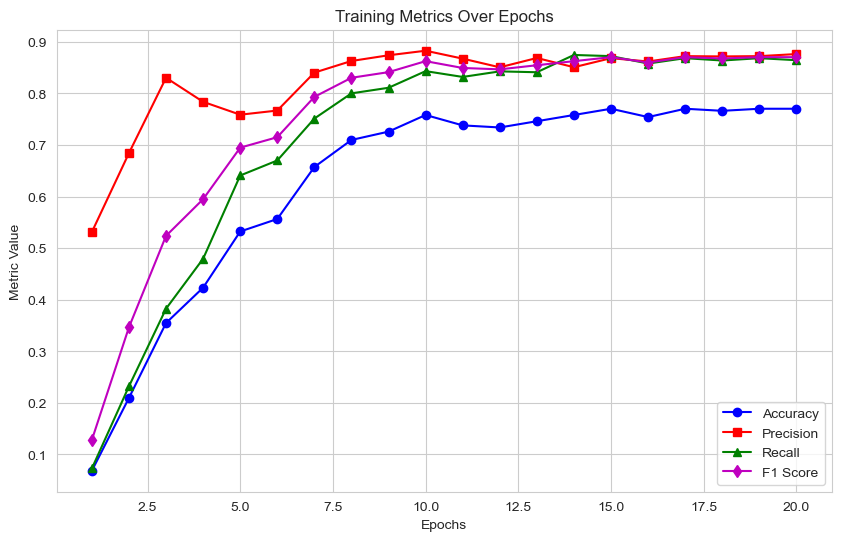

In [34]:
# Displaying the training performance over multiple epochs using evaluation metrics.
epochs = list(range(1, total_epochs+1))

plt.figure(figsize=(10, 6))
plt.plot(epochs, overall_accuracy, marker='o', linestyle='-', color='b', label='Accuracy')
plt.plot(epochs, overall_precision, marker='s', linestyle='-', color='r', label='Precision')
plt.plot(epochs, overall_recall, marker='^', linestyle='-', color='g', label='Recall')
plt.plot(epochs, overall_f1_score, marker='d', linestyle='-', color='m', label='F1 Score')

plt.xlabel("Epochs")
plt.ylabel("Metric Value")
plt.title("Training Metrics Over Epochs")
plt.legend()
plt.grid(True)
plt.show()